# Homework 2 #
Il seguente notebook ha come obiettivo quello di risolvere un problema di classificazione basato sul dataset ****CIFAR10****, esso contiene 60.000 immagini, appartenenti a 10 diverse classi (automobili, aeroplani...), a risoluzione 32x32 (dunque ogni osservazione ha 32x32 caratteristiche), a colori.

La prima fase, ai fini della risoluzione, deve necessariamente essere il caricamento del dataset.


In [15]:
#Prima di tutto, faccio l'import di tutte le librerie che potrebbero essere utili 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.utils import shuffle
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.tree import DecisionTreeClassifier, plot_tree

# PRE PROCESSING #
Prima di poter risolvere il problema è importante effettuare una buona fase di preprocessing.

Inizio dunque importando il dataset, Cifar10 contiene al suo interno 50000 osservazioni di train e 10000 di test, carico il dataset attraverso la funzione load_data dividendo in maniera diretta in train e test.

Inoltre, dato che l'idea è quella di ricercare i parametri migliori per ogni modello tramite GridSearch con Cross validation, non ho bisogno di creare uno split di validation, in quanto la fase di validation è relizzata appunto tramite cross validation a partire dai dati di train.

In [ ]:
from tensorflow.keras.datasets import cifar10 #import per cifar10
#la fase di caricamento presenta un warning, è relativo al caricamento di tensorflow, in particolare prova a
#caricare diversi plugin ma se li trova già caricati, quindi produce warning. Per evitare di mostrarlo, nascondo i warning
#con questo codice importo una funzione di os che mi permette di nascondere tutti i warning e gli errori fino al livello 2 
#(il livello 2 è quello degli errori, così elimina i warning)
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

(X_train, y_train), (X_test, y_test) = cifar10.load_data() 

print("La shape dei dati di train e di test è di", X_train.shape, X_test.shape)

Dopo la fase di caricamento eseguo delle operazioni sui dati, in modo da:
1) Favorire il confronto dei risultati ottenuti dai vari modelli;
2) Far funzionare i modelli di sklearn.

In particolare eseguo due operazioni:

Normalizzo il valore delle feature: esse variano nel range [0, 255], da nero a bianco, in quanto modellano
il colore assunto dai singoli pixel; i valori delle feature possono essere molto diversi dato che la scala è molto ampia, dato che modelli come KNN o SVM si basano su prossimità/distanza euclidea, avere i dati così distanti potrebbe essere un problema, dunque prima di tutto scalo i dati, in modo da far sì che tutte le feature siano in una scala omogenea e che tutte abbiano la stessa importanza.

In secondo luogo, i dati sono modellati come dei tensori a 3 dimensioni,infatti stampando la shape di X_train e di X_test nella cella precedente, si evinche che la dimensione è 32x32x3, i modelli di sklearn non accettano tensori a 3 dimensioni.

Il fatto che ci sia la terza dimensione ha senso nel dataset perché modella il canale (R, G, B). Quello che posso fare è rendere ogni osservazione modellata da un vettore di 32x32x3 elementi: ogni osservazione avrà dunque 3072 elementi.

In [17]:
"""
Adesso devo trasformare il tensore 3d in un vettore monodimensionale, per fare ciò uso la funzione reshape 
inserisco il -1 per specificare che devo fare reshape ad un array monodimensionale, si calcola poi in 
automatico la dimensione corretta, salvo in shape il numero di elementi che devono essere mantenuti, in quanto
la funzione reshape mi chiede come parametri il numero di elementi da mantenere e le dimensioni in cui voglio
fare reshape.
"""
shape_train = X_train.shape[0]
shape_test = X_test.shape[0]
X_train = X_train.reshape(shape_train, -1)
X_test = X_test.reshape(shape_test, -1)
y_train = y_train.reshape(-1)
y_test = y_test.reshape(-1)

fraction = 0.2
num_obs = len(y_train)
numt = len(y_test)
X_train = X_train[:int(num_obs*fraction)]
y_train = y_train[:int(num_obs*fraction)]
X_test = X_test[:int(numt*fraction)]
y_test= y_test[:int(numt*fraction)]

print("Le nuove dimensioni per train e test sono rispettivamente:", X_train.shape, X_test.shape)

SC = StandardScaler()
X_train = SC.fit_transform(X_train)
X_test = SC.transform(X_test)


Le nuove dimensioni per train e test sono rispettivamente: (10000, 3072) (2000, 3072)


# DEFINZIONE DELLA PIPELINE #

Per poter risolvere il problema ho deciso di utilizzare il seguente approccio:

Definisco una funzione pipeline che al suo interno esegue gridsearch; quello che voglio fare dunque è creare una funzione che accetta come parametri il nome del modello che voglio provare, un dizionario contenente gli iperparametri da testare (che ovviamente varia in base al modello), i dati di train che uso per l'allenamento di grid ed una porzione dei dati che prendo come validation per selezionare il modello migliore. 
Il return sarà un dizionario che contiene il nome del modello, la combinazione di parametri ottimale (sottoforma di dizionari) e risultati di metriche che calcolo nella funzione.
Salvo poi ognuno di questi dizionari in una lista, seleziono il modello migliore a partire dai valori di metriche che hanno ottenuto.

In particolare, non è necessario che io passi alla pipeline anche i dati di test in quanto proverò in test solo il modello che ha ottenuto le valutazioni migliori.


In [18]:
"""
Procedo prima a creare una porzione di validation vera e propria, che non uso in fit, questo fa sì che quando
calcolo accuracy e le altre matriche lo faccio su uno split che non ho mai visto.
Per fare ciò considero che i dati sono già divisi in train e test, sicché voglio evitare di intaccare lo split
di test e togliere campioni, quello che faccio è suddividere ulteriormente i dati di train.
Allo stato attuale esso conta 50k obs (contro le 10 del test), scelgo di assegnarne il 20% allo split di val.
"""
val_fraction = 0.2
num_obs = len(y_train)
num_obs_val = int(num_obs * 0.2)
X_val = X_train[:num_obs_val]
y_val = y_train[:num_obs_val]
X_train = X_train[num_obs_val:]
y_train = y_train[num_obs_val:]
print("Le nuove shape di train e val sono", X_train.shape, X_val.shape, "quelle di y sono", y_train.shape, y_val.shape)


Le nuove shape di train e val sono (8000, 3072) (2000, 3072) quelle di y sono (8000,) (2000,)


In [19]:
def pipeline(modello, param, X_train, y_train, X_val, y_val):
    #Questa prima fase serve per istanziare un modello dato il nome
    if(modello == 'Regressione Logica'): 
        model = LogisticRegression(max_iter = 10000)
    elif(modello == 'SVM'):
        model = SVC()
    elif(modello == 'KNN'):
        model = KNeighborsClassifier()
    elif (modello == 'Decision Trees'):
        model = DecisionTreeClassifier()
    else:
        print("ERRORE, MODELLO INSERITO NON VALIDO")
    #A questo punto posso procedere con l'istanziare un oggetto di tipo grid
    GS = GridSearchCV(estimator = model, param_grid = param, scoring = 'accuracy') #score tramite accuracy
    GS.fit(X_train, y_train) #alleno il modello sui dati di train
    best_model = GS.best_estimator_ #prendo il modello migliore
    train_predict = best_model.predict(X_train)
    val_predict = best_model.predict(X_val)

    #a questo punto posso calcolare le metriche che mi interessano, calcolo tutte le metriche che conosco
    val_accuracy = accuracy_score(y_val, val_predict)
    train_accuracy = accuracy_score(y_train, train_predict)
    val_precision = precision_score(y_val, val_predict, average = 'weighted')
    train_precision = precision_score(y_train, train_predict, average = 'weighted')
    val_recall = recall_score(y_val, val_predict, average = 'weighted')
    train_recall = recall_score(y_train, train_predict, average = 'weighted')
    val_f1 = f1_score(y_val, val_predict, average = 'weighted')
    train_f1 = f1_score(y_train, train_predict, average = 'weighted')
    report_val = classification_report(y_val, val_predict)
    report_train = classification_report(y_train, train_predict)

    #ora posso passare questi valori cosi calcolati come return della funzione, per farlo, costruisco un dizionario
    ret_dict = {
        'tipo_modello' : modello,
        'iper_parametri' : GS.best_params_,
        'modello_istanziato' : best_model,
        'risultati_validation' : {
            'accuracy' : val_accuracy,
            'precision' : val_precision,
            'recall' : val_recall,
            'f1_score' : val_f1,
            'val_report' : report_val
        },
        'risultati_train' : {
            'accuracy' : train_accuracy,
            'precision' : train_precision,
            'recall' : train_recall,
            'f1_score' : train_f1,
            'train_report' : report_train
        }
    }

    return ret_dict
    

Creo adesso un dizionario per ognuno dei modelli che voglio testare, contenente dei possibili valori per gli iperparametri del modello. Per ordine del codice creo un dizionario complessivo che contiene tutti i dizionari.

In [ ]:
dict_prova = {
    'Regressione Logica' : {
        'C' : [0.01, 0.1, 1]
    },
    'SVM' : {
        'C' : [0.01, 0.1, 1],
        'kernel' : ['linear', 'rbf']
    },
    'KNN' : {
        'n_neighbors' : [3, 5],
        'metric' : ['euclidean', 'manhattan']
    },
    'Decision Trees' : {
        'max_depth' : [4, 7, None],
        'min_samples_leaf': [1, 4],
        'criterion': ['entropy']
    }
}

# MODEL SELECTION #
A questo punto sono pronto a svolgere la fase di model selection, eseguo la pipeline su ognuno dei modelli con relativi dizionari, dopodiché scelgo il modello che ha ottenuto il valore di Accuracy più elevato.


Avevo anche pensato di poter scegliere il modello migliore secondo questo schema:
*controllo quale modello ha ottenuto i risultati più alti su tutte le metriche (quanti massimi ha ottenuto);

*a parità di massimi, scelgo il modello che ha il valore di **accuracy** più alto;

*a parità di accuracy, considero in ordine F1, precision e recall;

Ho comunque implementato il codice relativo a questa soluzione alternativa, che è commentata nella cella seguente.

Ho preferito l'approccio basato sull'accuracy in quanto è una metrica che fornisce un'idea più generale della capacità del modello di fare predizioni corrette; dopotutto ho considerato che un modello che otteneva valore di accuracy più alto era comunque da preferire ad uno che otteneva sia precision che recall più alte.


In [21]:
modelli = ['KNN', 'SVM', 'Decision Trees', 'Regressione Logica']
risultati = []

for i in modelli:
    ris = pipeline(i, dict_prova[i], X_train, y_train, X_val, y_val)
    risultati.append(ris)
    print("risultati ottenuti da: ", ris['tipo_modello'])
    print(ris['risultati_validation']['val_report'])
    
"""
max_acc = 0
max_pre = 0
max_rec = 0
max_f1 = 0

dict_mod = {
    'Regressione Logica' : 0,
    'KNN' : 0,
    'SVM' : 0,
    'Decision Trees' : 0
}

for i in risultati:
    if i['risultati_validation']['accuracy'] > max_acc:
        max_acc = i['risultati_validation']['accuracy']
        best_acc = i['tipo_modello']
    if i['risultati_validation']['precision'] > max_pre:
        max_pre = i['risultati_validation']['precision']
        best_pre = i['tipo_modello']
    if i['risultati_validation']['recall'] > max_rec:
        max_rec = i['risultati_validation']['recall']
        best_re = i['tipo_modello']
    if i['risultati_validation']['f1_score'] > max_f1:
        max_f1 = i['risultati_validation']['f1_score']
        best_f1 = i['tipo_modello']

dict_mod[best_acc] += 1
dict_mod[best_pre] += 1
dict_mod[best_re] += 1
dict_mod[best_f1] += 1
            

max_count = -1

print("Conteggio dei modelli migliori sulle 4 metriche:")
for modello, count in dict_mod.items():
    print(f"  {modello}: {count}")
    if(count > max_count):
        max_count = count
        best_name = modello

best_dict = {}
for i in risultati:
    if(i['tipo_modello'] == best_name):
        best_dict = i
"""

riconosciuto
fit fatto
risultati ottenuti da:  KNN
              precision    recall  f1-score   support

           0       0.32      0.50      0.39       202
           1       0.65      0.21      0.32       191
           2       0.22      0.50      0.31       203
           3       0.22      0.14      0.17       195
           4       0.23      0.39      0.29       214
           5       0.37      0.16      0.23       183
           6       0.35      0.30      0.33       207
           7       0.52      0.19      0.28       199
           8       0.41      0.58      0.48       203
           9       0.75      0.23      0.35       203

    accuracy                           0.32      2000
   macro avg       0.41      0.32      0.31      2000
weighted avg       0.40      0.32      0.32      2000

riconosciuto
fit fatto
risultati ottenuti da:  SVM
              precision    recall  f1-score   support

           0       0.57      0.51      0.54       202
           1       0.57      0

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: Undefined

fit fatto
risultati ottenuti da:  Regressione Logica
              precision    recall  f1-score   support

           0       0.43      0.42      0.42       202
           1       0.42      0.44      0.43       191
           2       0.27      0.28      0.27       203
           3       0.22      0.23      0.23       195
           4       0.31      0.26      0.28       214
           5       0.28      0.27      0.28       183
           6       0.37      0.40      0.39       207
           7       0.42      0.39      0.41       199
           8       0.42      0.49      0.45       203
           9       0.39      0.37      0.38       203

    accuracy                           0.35      2000
   macro avg       0.35      0.35      0.35      2000
weighted avg       0.35      0.35      0.35      2000



'\nmax_acc = 0\nmax_pre = 0\nmax_rec = 0\nmax_f1 = 0\n\ndict_mod = {\n    \'Regressione Logica\' : 0,\n    \'KNN\' : 0,\n    \'SVM\' : 0,\n    \'Decision Trees\' : 0\n}\n\nfor i in risultati:\n    if i[\'risultati_validation\'][\'accuracy\'] > max_acc:\n        max_acc = i[\'risultati_validation\'][\'accuracy\']\n        best_acc = i[\'tipo_modello\']\n    if i[\'risultati_validation\'][\'precision\'] > max_pre:\n        max_pre = i[\'risultati_validation\'][\'precision\']\n        best_pre = i[\'tipo_modello\']\n    if i[\'risultati_validation\'][\'recall\'] > max_rec:\n        max_rec = i[\'risultati_validation\'][\'recall\']\n        best_re = i[\'tipo_modello\']\n    if i[\'risultati_validation\'][\'f1_score\'] > max_f1:\n        max_f1 = i[\'risultati_validation\'][\'f1_score\']\n        best_f1 = i[\'tipo_modello\']\n\ndict_mod[best_acc] += 1\ndict_mod[best_pre] += 1\ndict_mod[best_re] += 1\ndict_mod[best_f1] += 1\n            \n\nmax_count = -1\n\nprint("Conteggio dei modelli mi

Adesso procedo con l'analisi dei risultati ottenuti dal modello, ne testo poi la capacità di generalizzazione sul test set dopo aver riaddestrato quello che ho stabilito essere il modello migliore sul train e sul validation uniti. 

Il fatto che svc abbia ottenuto i risultati migliori, e che in generale gli altri modelli abbiano ottenuto prestazioni non ottimali, (questo è visibile soprattuto dai risultati ottenuti da linear regression), suggerisce che probabilmente i dati non erano adatti ad un analisi lineare, aver utilizzato un kernel rbf mi in SVC mi ha permesso di ottenere dei risultati molto migliori rispetto a quelli ottenuti dagli altri modelli.

Ho ritenuto la presenza del warning molto interessante, l'ho discussa nel powerpoint. (In generale il warning mi indica che LR non predice mai certe classi: probabilmente i dati non sono adatti, come detto, ad un'analisi lineare, il risultato sono le scarse prestazioni mostrate dai modelli che si basano su analisi lineari come LR).


In [ ]:
max_acc = 0


for i in risultati:
    if i['risultati_validation']['accuracy'] > max_acc:
        max_acc = i['risultati_validation']['accuracy']
        best_acc = i['tipo_modello']

print("Il modello che ha ottenuto il risultato di accuracy più alto è", best_acc, ". Ne stampo i risultati ottenuti:")

best_dict = {}
for i in risultati:
    if(i['tipo_modello'] == best_acc):
        best_dict = i
        
print(f"Tipo modello: {best_dict['tipo_modello']}")
print(f"Iperparametri ottimali: {best_dict['iper_parametri']}")
print()

print("---- Prestazioni ottenute sul validation set ----")
print(f"Accuracy  : {best_dict['risultati_validation']['accuracy']}")
print(f"Precision : {best_dict['risultati_validation']['precision']}")
print(f"Recall    : {best_dict['risultati_validation']['recall']}")
print(f"F1 Score  : {best_dict['risultati_validation']['f1_score']}")
print()
print("Classification report (validation):")
print(best_dict['risultati_validation']['val_report'])
print()

print("---- Prestazioni su TRAIN ----")
print(f"Accuracy  : {best_dict['risultati_train']['accuracy']}")
print(f"Precision : {best_dict['risultati_train']['precision']}")
print(f"Recall    : {best_dict['risultati_train']['recall']}")
print(f"F1 Score  : {best_dict['risultati_train']['f1_score']}")
print()

X_train = np.concatenate((X_train, X_val), axis=0)
y_train = np.concatenate((y_train, y_val), axis=0)

best_mod = best_dict['modello_istanziato']
best_mod.fit(X_train, y_train)

test_predict = best_mod.predict(X_test)
accuracy = accuracy_score(y_test, test_predict)
precision = precision_score(y_test, test_predict, average = 'weighted')
recall = recall_score(y_test, test_predict, average = 'weighted')
f1 = f1_score(y_test, test_predict, average = 'weighted')
report = classification_report(y_test, test_predict)

print("I risultati sul test, ottenuti dal modello migliore, sono: ", report)


# VISUALIZZAZIONE RISULTATI SU TEST SET #
Per visualizzare al meglio i risultati ottenuti sul test set stampo la confusion matrix che fornisce indicazioni dettagliate su quanto bene il modello classifica ogni classe.
Per stampre la confusion matrix ho preso utilizzato la funzione che ci era stata fornita durante la terza esercitazione.

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
def plot_confusion_matrix(cm):
     class_labels = [f"Class {i}" for i in range(cm.shape[0])]
    
     plt.figure(figsize=(8, 6))
     sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
     plt.xlabel('Predicted')
     plt.ylabel('True')
     plt.title('Confusion Matrix')
     plt.show()


MTest = confusion_matrix(y_test, test_predict)
plot_confusion_matrix(MTest)

# CONFRONTO FRA I MODELLI #
Prima di concludere il notebook, ho pensato potesse essere conveniente confrontare graficamente i risultati ottenuti sulle varie matriche dai modelli allenati. 

Il confronto è svolto sui dati di validation, più significativo rispetto ad un confronto su dati di train.

Per eseguire il confronto ho scelto un grafico a barre, che permette di affiancare i risultati e di avere un'immediata comprensione di ciò che sta accadendo. Prova

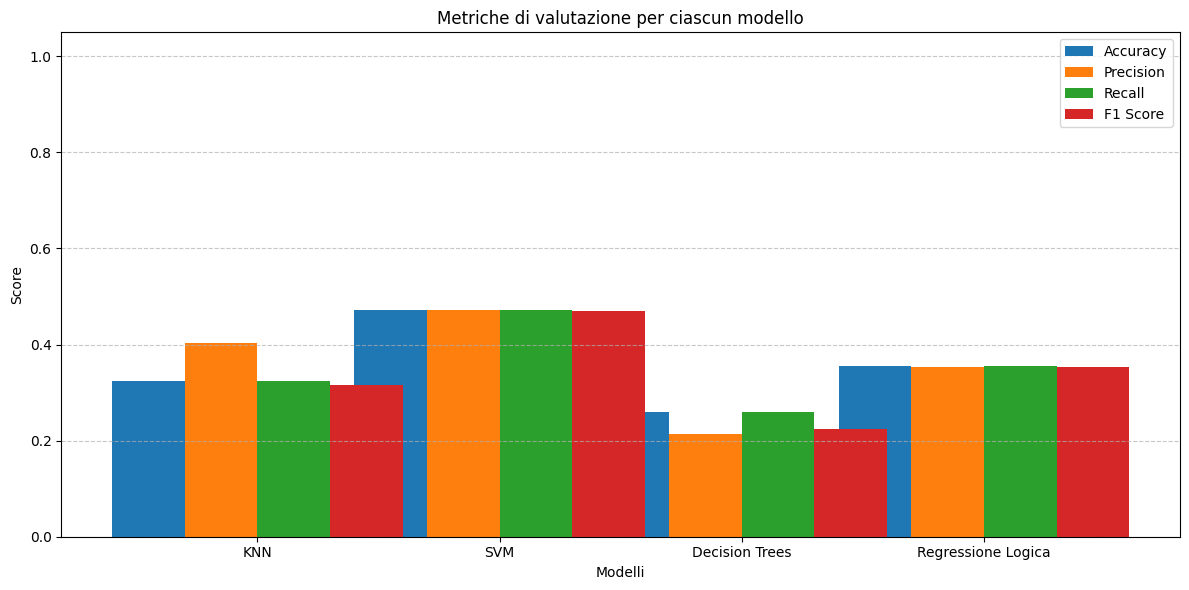

<Figure size 640x480 with 0 Axes>

In [24]:
x = np.arange(len(modelli))

accuracy_value =  []
precision_value = []
recall_value = []
f1_value = []
for i in risultati:
    for j in modelli:
        if i['tipo_modello']==j:
            accuracy_value.append(i['risultati_validation']['accuracy'])
            precision_value.append(i['risultati_validation']['precision'])
            recall_value.append(i['risultati_validation']['recall'])
            f1_value.append(i['risultati_validation']['f1_score'])

width = 0.3

plt.figure(figsize=(12, 6))

plt.bar(x - 1.5*width, accuracy_value, width, label='Accuracy')
plt.bar(x - 0.5*width, precision_value, width, label='Precision')
plt.bar(x + 0.5*width, recall_value, width, label='Recall')
plt.bar(x + 1.5*width, f1_value, width, label='F1 Score')

plt.xlabel('Modelli')
plt.ylabel('Score')
plt.title('Metriche di valutazione per ciascun modello')
plt.xticks(x, modelli)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#la uso per salvare il grafico come immagine
plt.savefig('grafico_risultati.png', dpi=300, bbox_inches='tight')